#Handwritten digits classification using neural network

In this notebook we will classify handwritten digits using a simple neural network which has only
input and output layers. We will than add a hidden layer and see how the performance of the
model improves

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
len(X_train)


60000

In [4]:
len(X_test)


10000

In [5]:
X_train[0].shape

(28, 28)

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

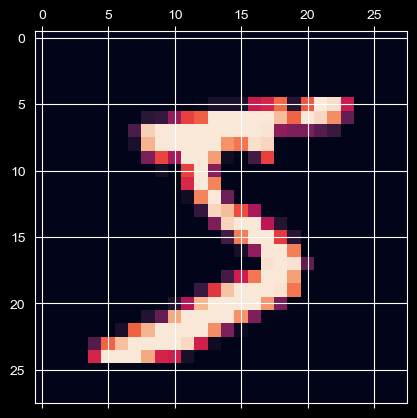

In [7]:
plt.matshow(X_train[0])


In [8]:
y_train[0]

np.uint8(5)

In [9]:
X_train[0]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [10]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)


In [11]:
X_train_flattened.shape

(60000, 784)

In [12]:
X_train_flattened[0]


array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

#Very simple neural network with no hidden layers


In [13]:
model = keras.Sequential([
 keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])
model.compile(optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])
model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
   1/1875 ━━━━━━━━━━━━━━━━━━━━ 3:42 119ms/step - accuracy: 0.1562 - loss: 150.3336

/opt/anaconda3/envs/da/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 293us/step - accuracy: 0.3299 - loss: 9.6433 
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step - accuracy: 0.3281 - loss: 6.0924
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step - accuracy: 0.3209 - loss: 5.6149
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 292us/step - accuracy: 0.3191 - loss: 5.5103
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 287us/step - accuracy: 0.3064 - loss: 5.3873


In [14]:
model.evaluate(X_test_flattened, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step - accuracy: 0.3226 - loss: 6.5560


[6.555974960327148, 0.32260000705718994]

In [15]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 205us/step


array([4.5567634e-31, 0.0000000e+00, 3.4374713e-25, 1.0000000e+00,
       2.1824892e-19, 1.0000000e+00, 0.0000000e+00, 1.0000000e+00,
       1.0000000e+00, 1.0000000e+00], dtype=float32)

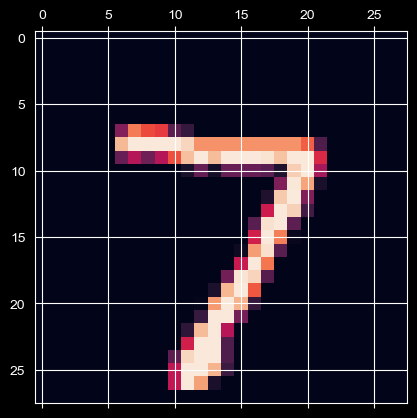

In [16]:
plt.matshow(X_test[0])


np.argmax finds a maximum element from an array and returns the index of it


In [17]:
np.argmax(y_predicted[0])


np.int64(3)

In [18]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]


In [19]:
y_predicted_labels[:5]

[np.int64(3), np.int64(0), np.int64(1), np.int64(0), np.int64(2)]

In [20]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 976,    0,    1,    0,    2,    0,    1,    0,    0,    0],
       [   8, 1123,    3,    0,    0,    1,    0,    0,    0,    0],
       [ 202,  335,  486,    2,    6,    0,    1,    0,    0,    0],
       [ 130,  219,  511,  150,    0,    0,    0,    0,    0,    0],
       [  52,  101,  182,  224,  422,    0,    0,    0,    1,    0],
       [ 197,   43,  188,  308,  112,   43,    1,    0,    0,    0],
       [ 219,   73,  589,   25,   32,   11,    9,    0,    0,    0],
       [  65,   93,  192,  624,   29,   16,    0,    9,    0,    0],
       [  52,  310,  400,  130,   34,   37,    2,    1,    8,    0],
       [  28,  100,  121,  559,  193,    3,    0,    5,    0,    0]],
      dtype=int32)>

Text(97.72222222222221, 0.5, 'Truth')

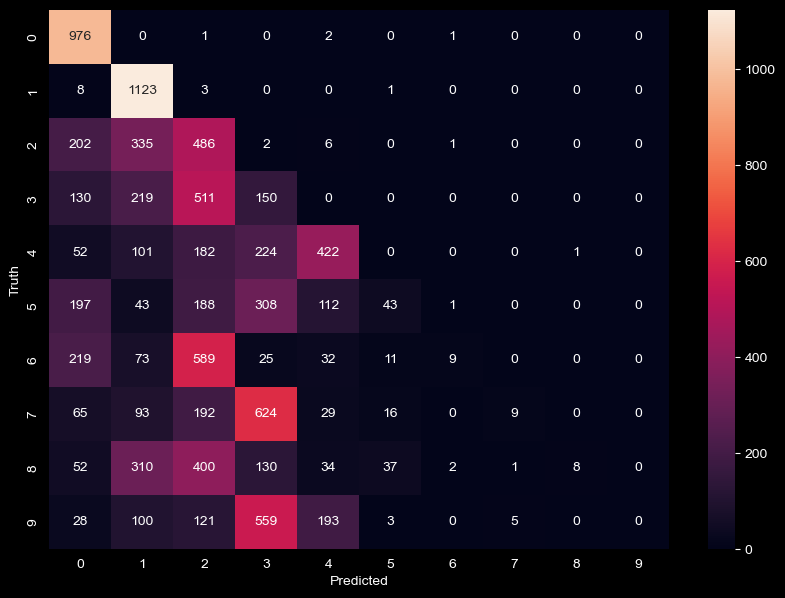

In [21]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


#Using hidden layer


In [22]:
model1 = keras.Sequential([
 keras.layers.Dense(100, input_shape=(784,), activation='relu'),
 keras.layers.Dense(10, activation='sigmoid')
])
model1.compile(optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])
model1.fit(X_train_flattened, y_train, epochs=5)


Epoch 1/5
   1/1875 ━━━━━━━━━━━━━━━━━━━━ 5:16 169ms/step - accuracy: 0.0938 - loss: 148.9319

/opt/anaconda3/envs/da/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.5723 - loss: 2.6162
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.5822 - loss: 0.4432
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.5566 - loss: 0.3370
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - accuracy: 0.5620 - loss: 0.2869
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.5699 - loss: 0.2405


In [23]:
model1.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - accuracy: 0.6044 - loss: 0.3067


[0.30669066309928894, 0.6043999791145325]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step


Text(97.72222222222221, 0.5, 'Truth')

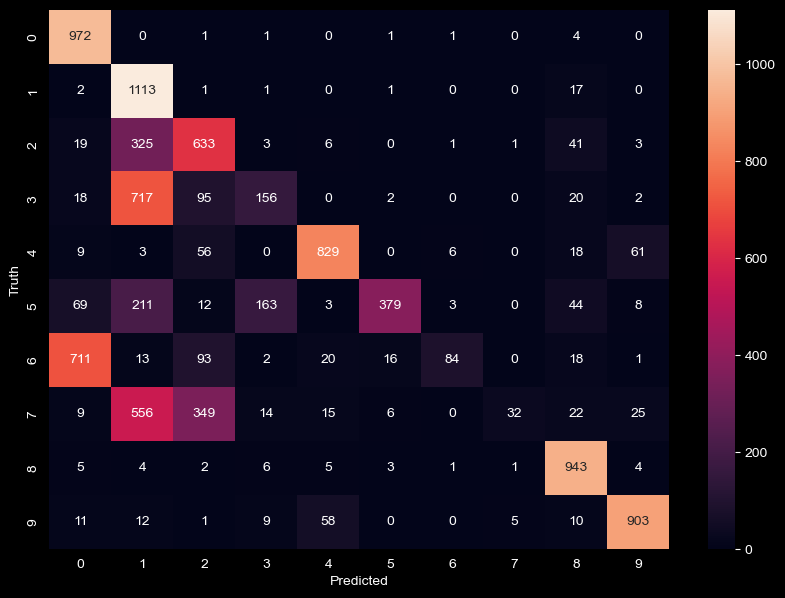

In [24]:

y_predicted = model1.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Using Flatten layer so that we don't have to call .reshape on input dataset


In [25]:
model2 = keras.Sequential([
 keras.layers.Flatten(input_shape=(28, 28)),
 keras.layers.Dense(100, activation='relu'),
 keras.layers.Dense(10, activation='sigmoid')
])
model2.compile(optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])
model2.fit(X_train, y_train, epochs=10)


Epoch 1/10
   1/1875 ━━━━━━━━━━━━━━━━━━━━ 5:04 163ms/step - accuracy: 0.0312 - loss: 162.9991

/opt/anaconda3/envs/da/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.4259 - loss: 2.5001
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.3730 - loss: 0.4138
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.2990 - loss: 0.2930
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.2781 - loss: 0.2439
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.2743 - loss: 0.2230
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 495us/step - accuracy: 0.2660 - loss: 0.2119
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 492us/step - accuracy: 0.2621 - loss: 0.2015
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.2587 - loss: 0.1948
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - accuracy: 0.2555 - loss: 0.1907
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - accuracy: 0.2671 - loss: 0.1818


In [26]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [27]:
from keras.utils import to_categorical, plot_model

plot_model(model2, to_file='mlp-mnist.png', show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [28]:
model2.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.2580 - loss: 0.3035


[0.30346933007240295, 0.257999986410141]

## network parameters
batch_size = 128
hidden_units = 256
dropout = 0.45

The batch_size argument indicates the number of data that we will use for each update of the model parameters.


Hidden_units shows the number of hidden units.


Dropout is a regularization technique used to prevent overfitting in neural networks.You’re telling the model to randomly "drop out" (set to zero) a fraction of neurons during each training step.

Example: Dropout(0.45) means 45% of neurons in that layer are ignored randomly at each update step.

In [29]:
#model is a 3-layer MLP with ReLU and dropout after each layer

from keras.models import Sequential
from keras.layers import Dense , Activation, Dropout
input_size = 28 * 28
batch_size = 128
hidden_units = 256
dropout = 0.45
num_labels = len(set(y_train))

model3 = Sequential()
model3.add(Dense(hidden_units, input_dim=input_size))
model3.add(Activation('relu'))
model3.add(Dropout(dropout))
model3.add(Dense(hidden_units))
model3.add(Activation('relu'))
model3.add(Dropout(dropout))
model3.add(Dense(num_labels))
model3.add(Activation('softmax'))

model3.compile(optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])
model3.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5


/opt/anaconda3/envs/da/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5471 - loss: 3.6090 
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6331 - loss: 1.2473
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7301 - loss: 0.9801
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7997 - loss: 0.7334
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8296 - loss: 0.6394


In [30]:
model3.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - accuracy: 0.9169 - loss: 0.3147


[0.3146986961364746, 0.9168999791145325]

Class work:
Build and train an Artificial Neural Network (ANN) model using the EMNIST dataset, preferably the EMNIST Letters split. The goal is to preprocess the data, design an appropriate ANN architecture, and achieve at least 90% accuracy on the test set.